In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealaxi/paysim1")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ealaxi/paysim1


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

In [58]:
DATA_PATH = "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [59]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [60]:
print(df["isFraud"].value_counts())

fraud_percent = (df["isFraud"].sum() / len(df)) * 100

print(f"Fraud Percentage: {fraud_percent:.4f}%")

isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Percentage: 0.1291%


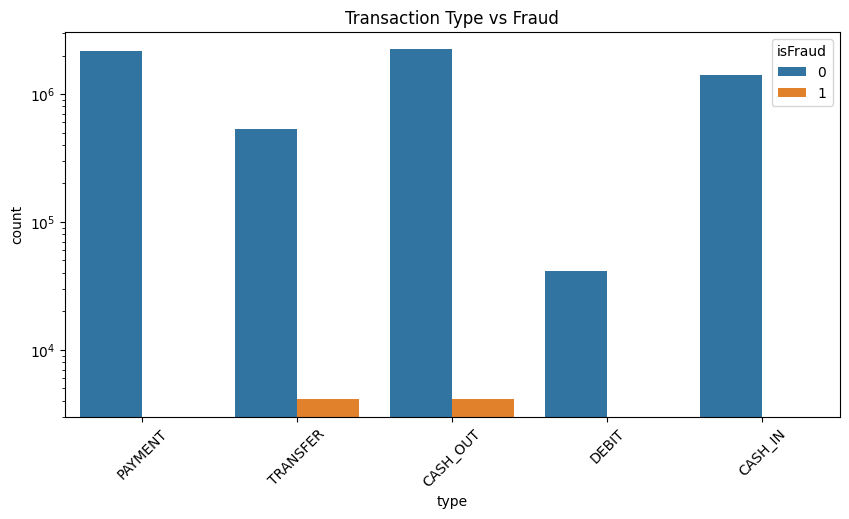

In [61]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="type",
    hue="isFraud",
    data=df
)

plt.yscale("log")

plt.title("Transaction Type vs Fraud")
plt.xticks(rotation=45)

plt.show()

In [63]:
df["nameOrig_txn_count"] = (
    df.groupby("nameOrig")["step"]
    .transform("count")
)

df["nameDest_txn_count"] = (
    df.groupby("nameDest")["step"]
    .transform("count")
)

In [65]:
df["nameOrig_mean_amount"] = (
    df.groupby("nameOrig")["amount"]
    .transform("mean")
)

df["nameDest_mean_amount"] = (
    df.groupby("nameDest")["amount"]
    .transform("mean")
)

In [66]:
df["hour"] = df["step"] % 24

In [68]:
large_threshold = df["amount"].quantile(0.99)

df["is_large_transaction"] = (
    df["amount"] > large_threshold
).astype(int)

In [69]:
df = pd.get_dummies(
    df,
    columns=["type"],
    drop_first=True
)

In [70]:
drop_cols = [
    "nameOrig",
    "nameDest",
    "isFlaggedFraud"
]

df = df.drop(columns=drop_cols)

In [71]:
X = df.drop(columns=[
    "isFraud"
])

y = df["isFraud"]

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [74]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.0013,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train_scaled)

IsolationForest(contamination=0.0013, n_jobs=-1, random_state=42)

In [75]:
iso_preds = iso_model.predict(X_test_scaled)

iso_preds = np.where(
    iso_preds == -1,
    1,
    0
)

In [76]:
print("Isolation Forest Results")

print(classification_report(
    y_test,
    iso_preds,
    digits=6
))

Isolation Forest Results
              precision    recall  f1-score   support

           0   0.998802  0.998814  0.998808   1270881
           1   0.073755  0.073037  0.073394      1643

    accuracy                       0.997619   1272524
   macro avg   0.536279  0.535926  0.536101   1272524
weighted avg   0.997607  0.997619  0.997613   1272524



In [77]:
neg = (y_train == 0).sum()

pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(scale_pos_weight)

773.7482496194825


In [78]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, ...)

In [80]:
xgb_probs = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

In [81]:
thresholds = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]

results = []

for t in thresholds:

    preds = (xgb_probs >= t).astype(int)

    precision = precision_score(y_test, preds)

    recall = recall_score(y_test, preds)

    f1 = f1_score(y_test, preds)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Threshold,Precision,Recall,F1 Score
0,0.50,0.294065,0.992088,0.453660
1,0.70,0.407389,0.986610,0.576663
2,0.80,0.504078,0.978089,0.665287
3,0.90,0.666948,0.961656,0.787637
4,0.95,0.814015,0.940353,0.872635
5,0.99,0.959239,0.859404,0.906581


In [82]:
threshold = 0.95

In [83]:
final_preds = (
    xgb_probs >= threshold
).astype(int)

In [84]:
print(classification_report(
    y_test,
    final_preds,
    digits=6
))

              precision    recall  f1-score   support

           0   0.999923  0.999722  0.999823   1270881
           1   0.814015  0.940353  0.872635      1643

    accuracy                       0.999646   1272524
   macro avg   0.906969  0.970038  0.936229   1272524
weighted avg   0.999683  0.999646  0.999658   1272524



In [85]:
cm = confusion_matrix(
    y_test,
    final_preds
)

print(cm)

[[1270528     353]
 [     98    1545]]


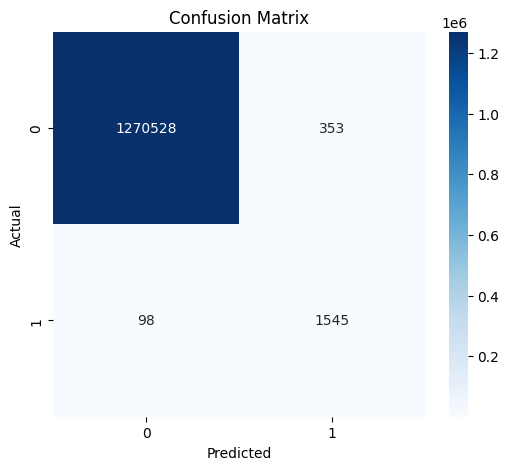

In [86]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [87]:
roc_auc = roc_auc_score(
    y_test,
    xgb_probs
)

print("ROC AUC:", roc_auc)

ROC AUC: 0.9998143353316868


In [88]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    xgb_probs
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

print("PR AUC:", pr_auc)

PR AUC: 0.9647703852290627


In [89]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
3,newbalanceOrig,0.370321
14,type_PAYMENT,0.269833
11,is_large_transaction,0.063403
2,oldbalanceOrg,0.057693
15,type_TRANSFER,0.046125
1,amount,0.040271
12,type_CASH_OUT,0.037598
10,hour,0.027860
4,oldbalanceDest,0.025129
8,nameOrig_mean_amount,0.023910


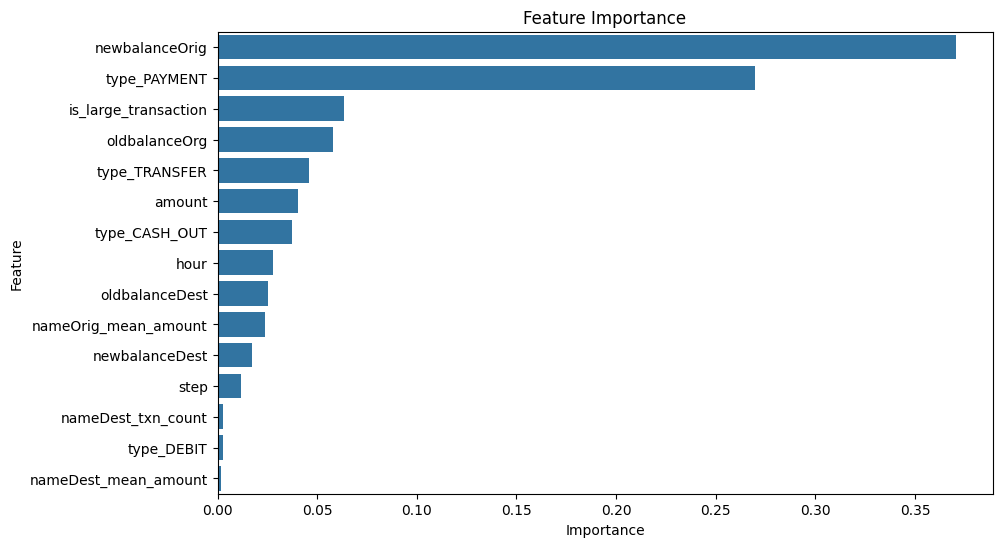

In [90]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(15)
)

plt.title("Feature Importance")

plt.show()

In [92]:
results = X_test.copy()

results["Actual"] = y_test.values

results["Fraud_Probability"] = xgb_probs

results["Predicted_Fraud"] = final_preds

In [93]:
red_flagged = results.sort_values(
    by="Fraud_Probability",
    ascending=False
)

red_flagged.head(20)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig_txn_count,nameDest_txn_count,nameOrig_mean_amount,nameDest_mean_amount,hour,is_large_transaction,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,Actual,Fraud_Probability,Predicted_Fraud
1030291,53,3640271.29,3640271.29,0.00,0.0,0.0,1,4,3640271.29,9.751472e+05,5,1,False,False,False,True,1,0.999996,1
1030623,78,2254934.36,2254934.36,0.00,0.0,0.0,1,13,2254934.36,3.385844e+05,6,1,False,False,False,True,1,0.999996,1
1070156,127,1848199.45,1848199.45,0.00,0.0,0.0,1,10,1848199.45,3.555972e+05,7,1,False,False,False,True,1,0.999996,1
1059516,101,2388251.16,2388251.16,0.00,0.0,0.0,1,9,2388251.16,3.357909e+05,5,1,False,False,False,True,1,0.999996,1
1059506,99,1515291.19,1515291.19,0.00,0.0,0.0,1,12,1515291.19,4.197236e+05,3,0,False,False,False,True,1,0.999996,1
1059672,116,2694857.26,2694857.26,0.00,0.0,0.0,1,7,2694857.26,5.444433e+05,20,1,False,False,False,True,1,0.999995,1
6296668,677,10000000.00,19295454.24,9295454.24,0.0,0.0,1,1,10000000.00,1.000000e+07,5,1,False,False,False,True,1,0.999995,1
6351223,702,10000000.00,13171085.59,3171085.59,0.0,0.0,1,1,10000000.00,1.000000e+07,6,1,False,False,False,True,1,0.999995,1
5563723,387,10000000.00,19110884.44,9110884.44,0.0,0.0,1,1,10000000.00,1.000000e+07,3,1,False,False,False,True,1,0.999995,1
5563721,387,10000000.00,29110884.44,19110884.44,0.0,0.0,1,2,10000000.00,5.016004e+06,3,1,False,False,False,True,1,0.999995,1


In [94]:
joblib.dump(
    xgb_model,
    "xgboost_fraud_model.pkl"
)

['xgboost_fraud_model.pkl']

In [95]:
joblib.dump(
    iso_model,
    "isolation_forest_model.pkl"
)

['isolation_forest_model.pkl']

In [96]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [97]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

['feature_names.pkl']

In [98]:
import os

os.listdir()

['isolation_forest_model.pkl',
 'scaler.pkl',
 '.virtual_documents',
 'xgboost_fraud_model.pkl',
 'feature_names.pkl']

In [3]:
# !pip install xgboost imbalanced-learn joblib -q

In [4]:
# import pandas as pd
# import numpy as np
# import os
# import warnings
# warnings.filterwarnings("ignore")

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.metrics import (
#     classification_report,
#     confusion_matrix,
#     roc_auc_score,
#     precision_recall_curve,
#     auc
# )

# from sklearn.ensemble import IsolationForest

# from imblearn.over_sampling import SMOTE
# from imblearn.combine import SMOTETomek

# from xgboost import XGBClassifier

# import matplotlib.pyplot as plt
# import seaborn as sns

# import joblib

In [5]:
# DATA_PATH = "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv"

# df = pd.read_csv(DATA_PATH)

# print(df.shape)
# df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
fraud_percent = (df["isFraud"].sum() / len(df)) * 100

print(f"Fraud Percentage: {fraud_percent:.4f}%")

Fraud Percentage: 0.1291%


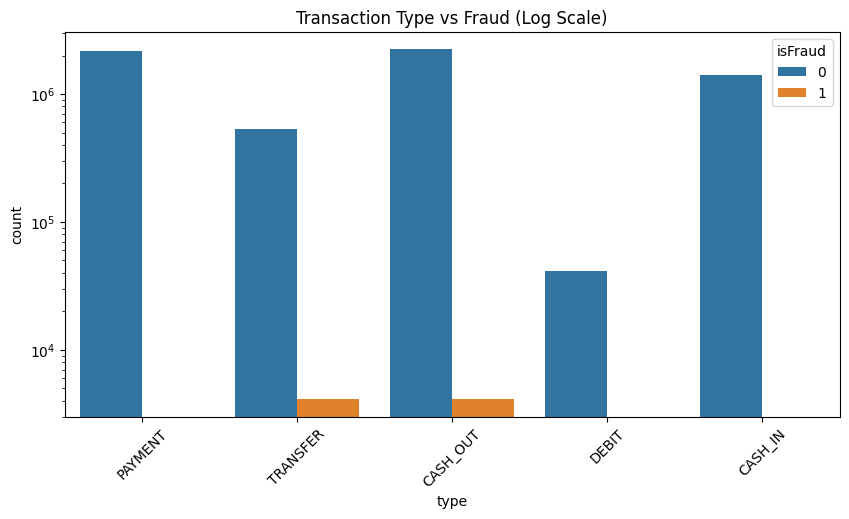

In [9]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    x="type",
    hue="isFraud",
    data=df
)

plt.yscale("log")

plt.title("Transaction Type vs Fraud (Log Scale)")
plt.xticks(rotation=45)

plt.show()

In [10]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

fraud_by_type

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


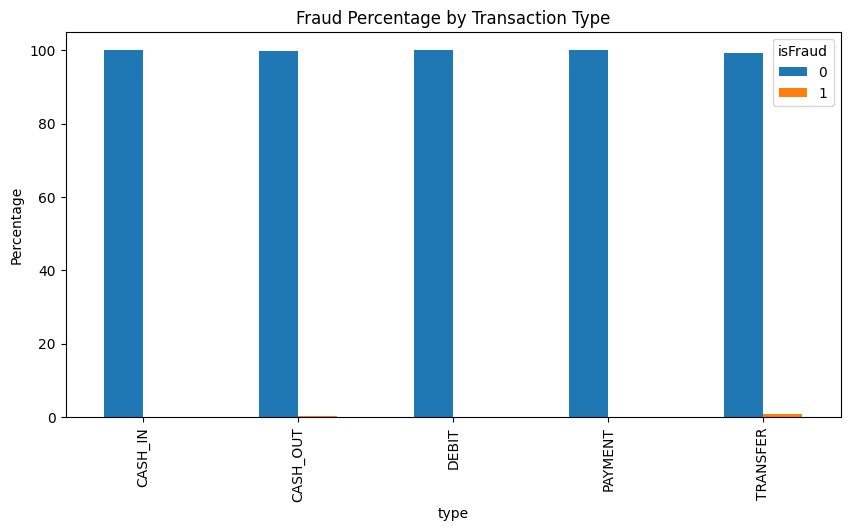

In [11]:
fraud_by_type.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Percentage")
plt.title("Fraud Percentage by Transaction Type")

plt.show()

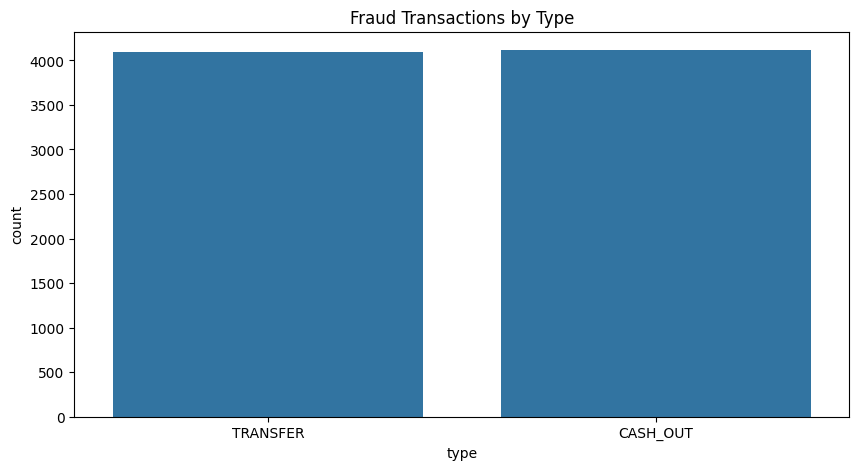

In [12]:
plt.figure(figsize=(10,5))

fraud_only = df[df["isFraud"] == 1]

sns.countplot(
    x="type",
    data=fraud_only
)

plt.title("Fraud Transactions by Type")

plt.show()

In [13]:
df["orig_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

df["dest_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

df[[
    "orig_balance_error",
    "dest_balance_error"
]].head()

,orig_balance_error,dest_balance_error
0,0.0,9839.64
1,0.0,1864.28
2,0.0,181.00
3,0.0,21363.00
4,0.0,11668.14


In [14]:
df["nameOrig_txn_count"] = (
    df.groupby("nameOrig")["step"]
    .transform("count")
)

In [15]:
df["nameDest_txn_count"] = (
    df.groupby("nameDest")["step"]
    .transform("count")
)

In [16]:
df["nameOrig_mean_amount"] = (
    df.groupby("nameOrig")["amount"]
    .transform("mean")
)

In [17]:
df["nameDest_mean_amount"] = (
    df.groupby("nameDest")["amount"]
    .transform("mean")
)

In [18]:
df["hour"] = df["step"] % 24

df["hour"].head()

0    1
1    1
2    1
3    1
4    1
Name: hour, dtype: int64

In [19]:
large_threshold = df["amount"].quantile(0.99)

print(large_threshold)

1615979.4715999917


In [20]:
df["is_large_transaction"] = (
    df["amount"] > large_threshold
).astype(int)

In [21]:
df["orig_zero_balance"] = (
    df["newbalanceOrig"] == 0
).astype(int)

df["dest_zero_balance"] = (
    df["newbalanceDest"] == 0
).astype(int)

In [22]:
df = pd.get_dummies(
    df,
    columns=["type"],
    drop_first=True
)

In [23]:
drop_cols = [
    "nameOrig",
    "nameDest",
    "isFlaggedFraud"
]

df = df.drop(columns=drop_cols)

df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_error,dest_balance_error,nameOrig_txn_count,...,nameOrig_mean_amount,nameDest_mean_amount,hour,is_large_transaction,orig_zero_balance,dest_zero_balance,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,9839.64,1,...,9839.64,9839.640000,1,0,0,1,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,1864.28,1,...,1864.28,1864.280000,1,0,0,1,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0.0,181.00,1,...,181.00,225517.832045,1,0,1,1,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0.0,21363.00,1,...,181.00,439444.208049,1,0,1,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,11668.14,1,...,11668.14,11668.140000,1,0,0,1,False,False,True,False


In [24]:
df.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'orig_balance_error', 'dest_balance_error',
       'nameOrig_txn_count', 'nameDest_txn_count', 'nameOrig_mean_amount',
       'nameDest_mean_amount', 'hour', 'is_large_transaction',
       'orig_zero_balance', 'dest_zero_balance', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

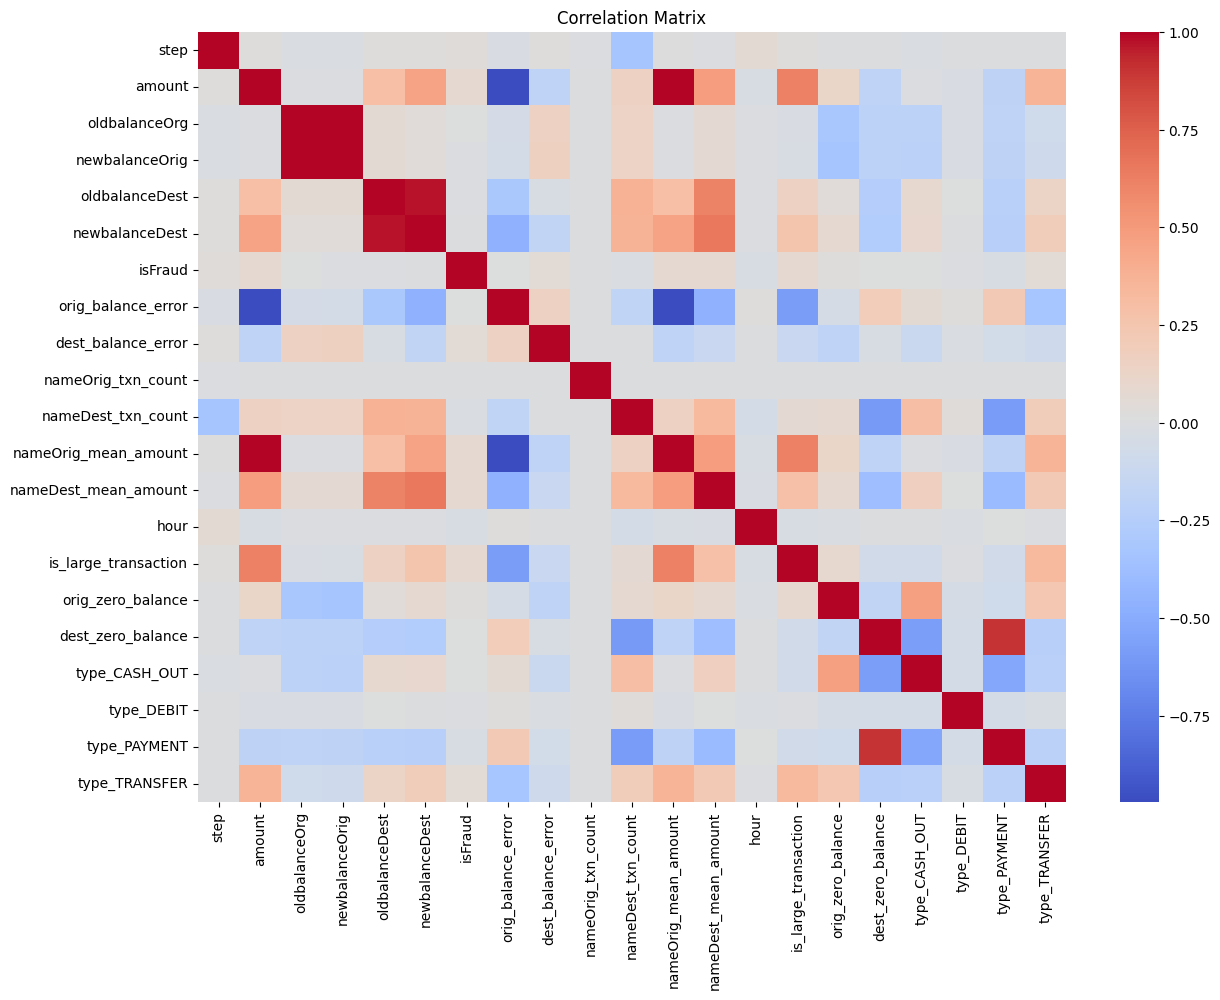

In [25]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [26]:
df.isnull().sum()

step                    0
amount                  0
oldbalanceOrg           0
newbalanceOrig          0
oldbalanceDest          0
newbalanceDest          0
isFraud                 0
orig_balance_error      0
dest_balance_error      0
nameOrig_txn_count      0
nameDest_txn_count      0
nameOrig_mean_amount    0
nameDest_mean_amount    0
hour                    0
is_large_transaction    0
orig_zero_balance       0
dest_zero_balance       0
type_CASH_OUT           0
type_DEBIT              0
type_PAYMENT            0
type_TRANSFER           0
dtype: int64

In [27]:
df.dtypes

step                      int64
amount                  float64
oldbalanceOrg           float64
newbalanceOrig          float64
oldbalanceDest          float64
newbalanceDest          float64
isFraud                   int64
orig_balance_error      float64
dest_balance_error      float64
nameOrig_txn_count        int64
nameDest_txn_count        int64
nameOrig_mean_amount    float64
nameDest_mean_amount    float64
hour                      int64
is_large_transaction      int64
orig_zero_balance         int64
dest_zero_balance         int64
type_CASH_OUT              bool
type_DEBIT                 bool
type_PAYMENT               bool
type_TRANSFER              bool
dtype: object

In [28]:
np.isinf(df).sum()

step                    0
amount                  0
oldbalanceOrg           0
newbalanceOrig          0
oldbalanceDest          0
newbalanceDest          0
isFraud                 0
orig_balance_error      0
dest_balance_error      0
nameOrig_txn_count      0
nameDest_txn_count      0
nameOrig_mean_amount    0
nameDest_mean_amount    0
hour                    0
is_large_transaction    0
orig_zero_balance       0
dest_zero_balance       0
type_CASH_OUT           0
type_DEBIT              0
type_PAYMENT            0
type_TRANSFER           0
dtype: int64

In [29]:
X = df.drop("isFraud", axis=1)

y = df["isFraud"]

print(X.shape)
print(y.shape)

(6362620, 20)
(6362620,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5090096, 20)
(1272524, 20)


In [31]:
print("Train Fraud Ratio")
print(y_train.value_counts(normalize=True))

print("\nTest Fraud Ratio")
print(y_test.value_counts(normalize=True))

Train Fraud Ratio
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

Test Fraud Ratio
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5090096, 20)
(1272524, 20)


In [34]:
neg = (y_train == 0).sum()

pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(scale_pos_weight)

773.7482496194825


In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [36]:
xgb_model.fit(
    X_train_scaled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, ...)

In [37]:
xgb_preds = xgb_model.predict(X_test_scaled)

xgb_probs = xgb_model.predict_proba(X_test_scaled)[:,1]

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    xgb_preds,
    digits=6
))

              precision    recall  f1-score   support

           0   0.999997  0.999995  0.999996   1270881
           1   0.996353  0.997565  0.996959      1643

    accuracy                       0.999992   1272524
   macro avg   0.998175  0.998780  0.998477   1272524
weighted avg   0.999992  0.999992  0.999992   1272524



In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    xgb_preds
)

print(cm)

[[1270875       6]
 [      4    1639]]


In [40]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
14,orig_zero_balance,0.302031
6,orig_balance_error,0.222833
3,newbalanceOrig,0.173515
18,type_PAYMENT,0.133538
2,oldbalanceOrg,0.034483
15,dest_zero_balance,0.032025
10,nameOrig_mean_amount,0.026963
1,amount,0.021744
17,type_DEBIT,0.018818
12,hour,0.010184


## 2nd attempt


In [41]:
leaky_features = [
    "orig_balance_error",
    "dest_balance_error",
    "orig_zero_balance",
    "dest_zero_balance"
]

In [42]:
X = df.drop(columns=[
    "isFraud",
    "orig_balance_error",
    "dest_balance_error",
    "orig_zero_balance",
    "dest_zero_balance"
])

y = df["isFraud"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [45]:
neg = (y_train == 0).sum()

pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

In [46]:
xgb_model_2 = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model_2.fit(
    X_train_scaled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, ...)

In [55]:
xgb_preds_2 = xgb_model_2.predict(
    X_test_scaled
)

xgb_probs_2 = xgb_model_2.predict_proba(
    X_test_scaled
)[:,1]
threshold = 0.95

xgb_preds_threshold = (
    xgb_probs_2 >= threshold
).astype(int)

In [56]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    xgb_preds_threshold,
    digits=6
))

              precision    recall  f1-score   support

           0   0.999923  0.999722  0.999823   1270881
           1   0.814015  0.940353  0.872635      1643

    accuracy                       0.999646   1272524
   macro avg   0.906969  0.970038  0.936229   1272524
weighted avg   0.999683  0.999646  0.999658   1272524

